In [ ]:
# Remember to pip install pandas, matplotlib, scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull, QhullError

# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline 

In [ ]:
# In the source dataset, 0 represents an unrecorded measurement.
# Reads the CSV file and sets 0 values to NULL
df = pd.read_csv(
    "Allsharkteeth.csv", 
    skipinitialspace = True,
    na_values = "0"
)
data_frame = df.copy(deep=True)
#data_frame

In [ ]:
# Counts how many NULL values in each attribute
count = data_frame.isnull().sum()
count

Locality       0
Specimen #     0
Taxon          0
Position       0
BCW            0
CH             2
DCL            2
IDCL           2
IMCL           2
LCH           68
LCW           66
MCL            2
PCH            2
PCW            2
RH            13
RW            12
TH             0
DS             2
CDS           67
RA            22
dtype: int64

In [ ]:
# I'm going to drop the values for:
#   LCH, LCW, CDS
# Because if there are species that don't have that attribute at all, it is not 
# a reliable measurment to use in PCA

cols_to_drop = ['LCH', 'LCW', 'CDS']
data_frame = data_frame.drop(columns=cols_to_drop)

# I'm going to impute the overall median value for all other attributes.

cols_to_impute = [ 
    'RH', 'RW', 'RA', 'CH', 'DCL', 'IDCL', 'IMCL', 'MCL', 'PCH', 'PCW', 'DS'
]

overall_medians = data_frame[cols_to_impute].median()
data_frame[cols_to_impute] = data_frame[cols_to_impute].fillna(overall_medians)


# Sanity checks

assert data_frame[cols_to_impute].isna().sum().sum() == 0
#print(data_frame[data_frame['RA'].isnull()])
#data_frame['RA'] = data_frame['RA'].fillna(data_frame['RA'].median())

#count = data_frame.isna().sum()
#count
#data_frame

In [ ]:
# Previous data handling imputed missing values with taxon median.
# This was changed to avoid qualitative bias influencing PCA.

#taxon_medians = data_frame.groupby('Taxon')[cols_to_impute].transform('median')
#data_frame[cols_to_impute] = data_frame[cols_to_impute].fillna(taxon_medians)
# RA still has missing values for Taxa where all RA values are missing
#count = data_frame.isna().sum()
#data_frame['RA'] = data_frame['RA'].fillna(0)

In [ ]:
# Only numerical data
num_data = data_frame.drop(
    columns=['Locality', 'Specimen #', 'Taxon', 'Position']
)

# Standardizing data
scaler = StandardScaler()
scaled_array = scaler.fit_transform(num_data)

scaled_data = pd.DataFrame(
    scaled_array,
    columns = num_data.columns,
    index = num_data.index
)


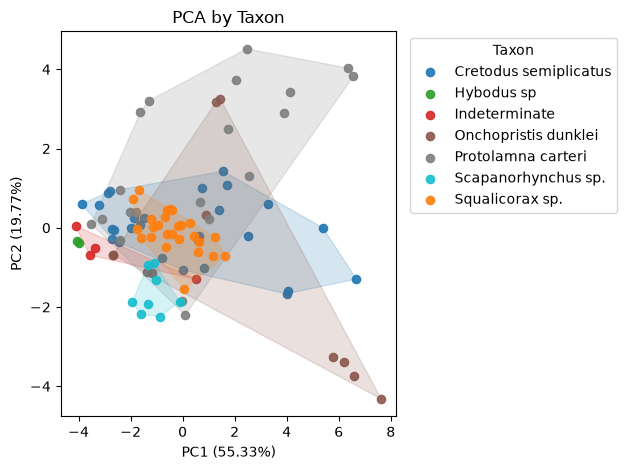

In [ ]:
# Does the PCA
pca = PCA(n_components=2, svd_solver="full")
pca_scores = pca.fit_transform(scaled_data)

# Converts PCA back to a usable graph to be plotted
taxon = data_frame.loc[scaled_data.index, 'Taxon']
pca_data = pd.DataFrame (
    pca_scores, 
    columns = ["PC1", "PC2"],
    index = scaled_data.index
)
pca_data['Taxon'] = taxon

# Plots the graph
for name, g in pca_data.groupby("Taxon"):
    sc = plt.scatter(g["PC1"], g["PC2"], s=35, alpha=0.9, label=name)
    color = sc.get_facecolors()[0]
    if len(g) >= 3:
        pts = g[["PC1", "PC2"]].to_numpy()
        try:
            hull = ConvexHull(pts)
            hull_pts = pts[hull.vertices]
            plt.fill(
                hull_pts[:, 0], hull_pts[:, 1],
                facecolor=color, alpha=0.18,   # translucent fill
                edgecolor=color, linewidth=1   # matching outline
            )
        except QhullError:
            pass

# Variance Ratio
var = pca.explained_variance_ratio_
plt.xlabel(f"PC1 ({var[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({var[1]*100:.2f}%)")

# Title
plt.title("PCA by Taxon")
plt.legend(title="Taxon", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()




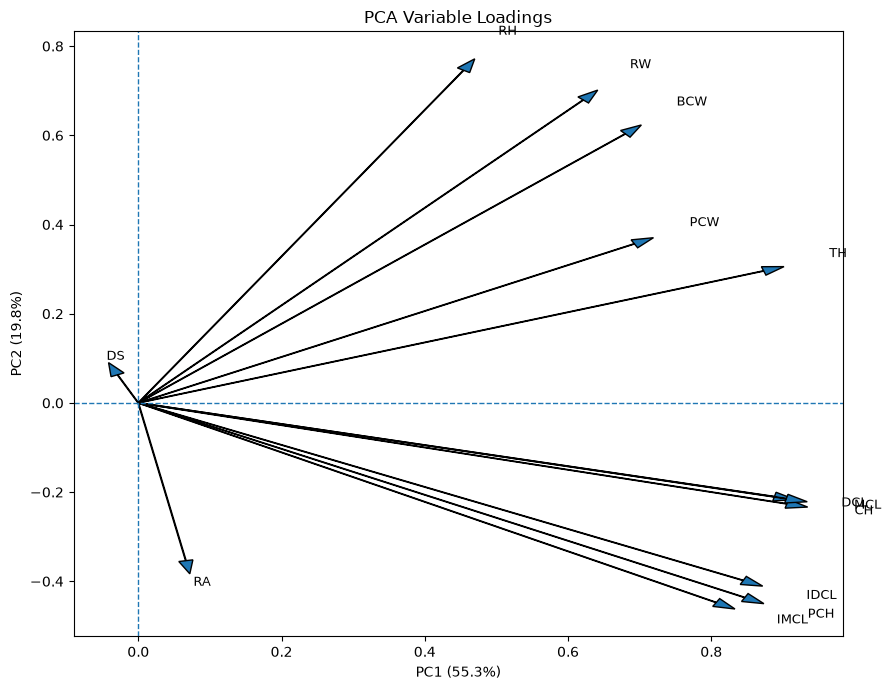

In [ ]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

plt.figure(figsize=(9, 7))
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

for i, col in enumerate(scaled_data.columns):
    x, y = loadings[i, 0], loadings[i, 1]
    plt.arrow(0, 0, x, y, head_width=0.02, length_includes_head=True)
    plt.text(x * 1.07, y * 1.07, col, fontsize=9)

plt.title("PCA Variable Loadings")
plt.xlabel(f"PC1 ({var[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var[1]*100:.1f}%)")
plt.tight_layout()
plt.show()

In [ ]:
# pca is already fit on scaled_data
weights = pd.DataFrame(
    pca.components_.T,
    index=scaled_data.columns,
    columns=["PC1", "PC2"]
)

# biggest absolute influence on each PC (signed values kept)
pc1_ranked = weights["PC1"].abs().sort_values(ascending=False)
pc2_ranked = weights["PC2"].abs().sort_values(ascending=False)

print("Top contributors to PC1:")
print(weights.loc[pc1_ranked.index].head(10), "\n")

print("Top contributors to PC2:")
print(weights.loc[pc2_ranked.index].head(10))


Top contributors to PC1:
           PC1       PC2
CH    0.346701 -0.144951
MCL   0.346468 -0.137533
DCL   0.340302 -0.134662
TH    0.334440  0.189623
PCH   0.324021 -0.279326
IDCL  0.323395 -0.254940
IMCL  0.309041 -0.286749
PCW   0.266831  0.229863
BCW   0.260555  0.386735
RW    0.237956  0.435259 

Top contributors to PC2:
           PC1       PC2
RH    0.174247  0.478739
RW    0.237956  0.435259
BCW   0.260555  0.386735
IMCL  0.309041 -0.286749
PCH   0.324021 -0.279326
IDCL  0.323395 -0.254940
RA    0.026678 -0.237822
PCW   0.266831  0.229863
TH    0.334440  0.189623
CH    0.346701 -0.144951


The first two prinipal components account for 75.1% of varience (PC1 = 55.3%, PC2 = 19.8%). Because morphalogical measurments are the top contributors to PC1, PC1 probably represents overall tooth size. PC2 likely represents tooth porportions/shape. Heavy overlap on the graph might mean that although some species have noticably different tooth shapes, many are similar enough that measurments alone can't always tell you the species. 